In [1]:
from re import L
from pesummary.io import read
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import json

def plot_median_histgram(outdir, label, params, file_index):

    plot_median_dict = {}
    for key in params:
        plot_median_dict[key] = []

    for num in file_index:
        json_file_path = f'{outdir}_{num}/{label}_{num}_result.json'
        data = read(json_file_path, package='core')
        posterior_samples = data.samples_dict.to_pandas()
        injection_parameters_dict = data.injection_parameters
        
        for key in params:
            median_value = np.percentile(posterior_samples[key], 50)
            plot_median_dict[key].append(median_value)

    bins = 35
    for key, values in plot_median_dict.items():
        Y, X, _  = plt.hist(values, bins=bins, edgecolor='black')
        plt.xlabel(key)
        plt.rcParams["font.size"] = 15
        plt.rcParams["axes.axisbelow"] = True
        plt.ylabel('counts')
        plt.grid(axis='x')
        #y_max = int(max(Y)) + 1
        #plt.yticks(np.arange(0, y_max, 2))
        plt.show()

def plot_snr_histgram(outdir, label, file_index):
    snr_dict = {}
    detectors = ['H1', 'L1', 'V1']
    for detector in detectors:
        snr_dict[detector] = []
    for num in file_index:
        json_file_path = f'{outdir}_{num}/{label}_{num}_result.json'
        # json_file_path = f'{outdir}_{num}/pp_one_mode_{num}_result.json'
        with open(json_file_path, 'r') as file:
            others_data = json.load(file)
        for detector in detectors:
            snr_dict[detector].append(others_data['meta_data']['likelihood']['interferometers'][detector]['optimal_SNR'])
    
    snr_squared_list = np.zeros(len(file_index))
    for detector in detectors:
        snr_squared_list += np.array(snr_dict[detector]) ** 2
    snr_list = np.sqrt(snr_squared_list)

    # bins = 35
    bins = np.logspace(-0, 5, 35)
    plt.gca().set_xscale("log")
    Y, X, _ = plt.hist(snr_list, bins=bins, edgecolor='black')
    plt.xlabel('SNR')
    plt.rcParams["font.size"] = 15
    plt.rcParams["axes.axisbelow"] = True
    plt.ylabel('counts')
    plt.grid(axis='x')
    #y_max = int(max(Y)) + 1
    #plt.yticks(np.arange(0, y_max, 2))
    plt.show()

/home/hayato.imafuku/research/env/lib/python3.11/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


01:43 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:43 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:43 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:43 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:43 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:43 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:43 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:43 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:43 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:43 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:43 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:43 bilby WARNING :

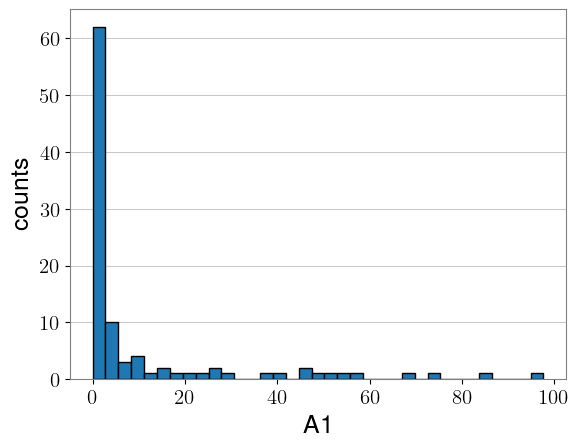

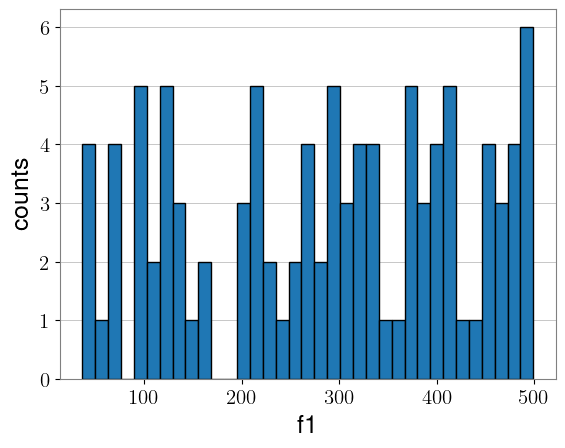

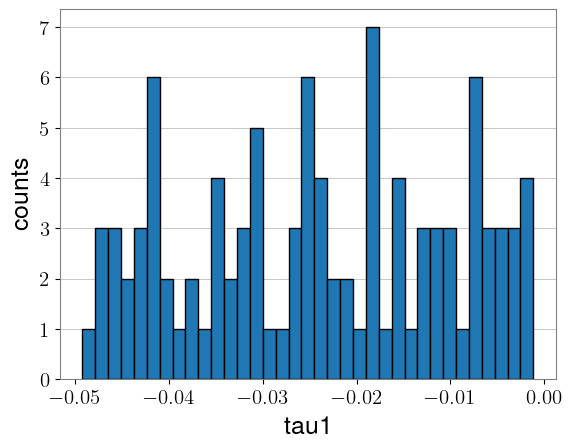

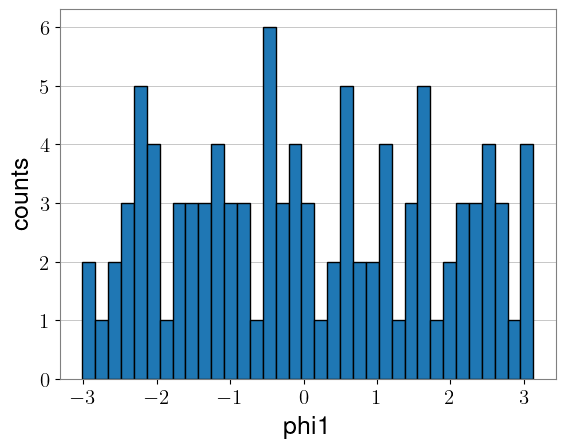

In [17]:
name = 'pp_one_mode'
outdir = './outdirs/{}/outdir_{}'.format(name, name)
label = name
file_index = np.arange(0, 100, 1)
params = ['A1', 'f1', 'tau1', 'phi1']
plot_median_histgram(outdir, label, params, file_index)

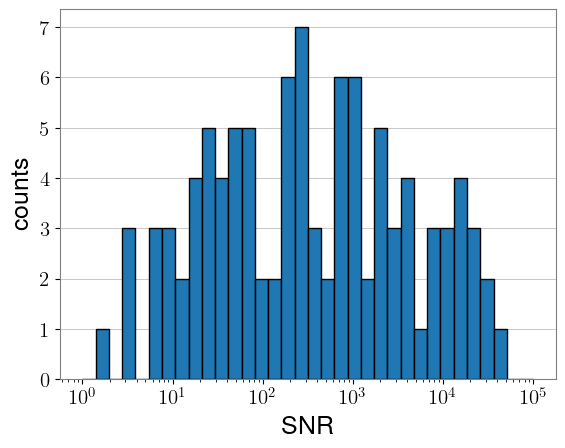

In [ ]:
name = 'pp_one_mode'
outdir = './outdirs/{}/outdir_{}'.format(name, name)
label = name
file_index = np.arange(0, 100, 1)
plot_snr_histgram(outdir, label, file_index)

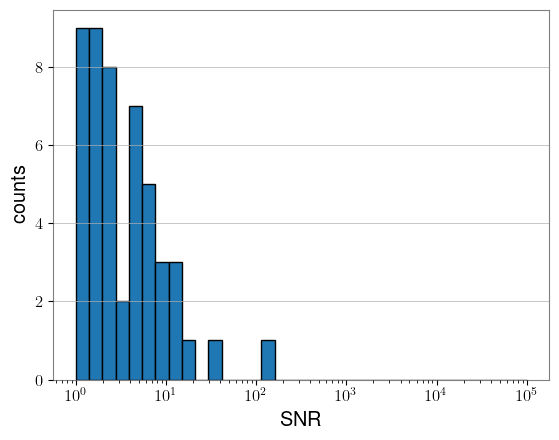

In [4]:
name = 'pp_one_mode_DSPram_APriUni'
outdir = './outdirs/{}/outdir_{}'.format(name, name)
label = name
file_index = np.arange(0, 100, 1)
plot_snr_histgram(outdir, label, file_index)

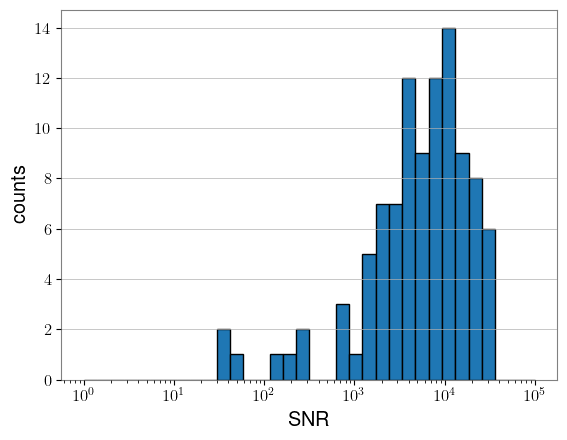

In [2]:
name = 'pp_two_mode_generated_by_OTparam_corrected'
outdir = './outdirs/{}/outdir_{}'.format(name, name)
label = name
file_index = np.arange(0, 100, 1)
plot_snr_histgram(outdir, label, file_index)